In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("penguins.csv")

In [3]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,MALE
1,39.5,17.4,186.0,3800.0,FEMALE
2,40.3,18.0,195.0,3250.0,FEMALE
3,NaN,NaN,NaN,NaN,NaN
4,36.7,19.3,193.0,3450.0,FEMALE


In [4]:
df.isnull().sum()

culmen_length_mm     2
culmen_depth_mm      2
flipper_length_mm    2
body_mass_g          2
sex                  9
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   culmen_length_mm   342 non-null    float64
 1   culmen_depth_mm    342 non-null    float64
 2   flipper_length_mm  342 non-null    float64
 3   body_mass_g        342 non-null    float64
 4   sex                335 non-null    object 
dtypes: float64(4), object(1)
memory usage: 13.6+ KB


In [6]:
df["sex"].value_counts()

sex
MALE      169
FEMALE    165
.           1
Name: count, dtype: int64

In [7]:
df = df[df["sex"] != "."]
df["sex"] = df["sex"].map({"MALE":1,"FEMALE":0})

In [8]:
import math
def plot_all_histograms(df,title_prefix = ""):
    num_cols = df.select_dtypes(include=[np.number]).columns
    n_cols=3
    n_rows = math.ceil(len(num_cols) / n_cols)

    plt.figure(figsize=(5*n_cols,4*n_rows))

    for i, col in enumerate(num_cols,1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col],kde=True,bins = 30)
        plt.title(f"{title_prefix} {col}")
        plt.xlabel("")
        plt.ylabel("")

    plt.tight_layout()
    plt.show()

In [9]:
df =df.dropna()

In [10]:
df.isnull().sum()

culmen_length_mm     0
culmen_depth_mm      0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [11]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,1.0
1,39.5,17.4,186.0,3800.0,0.0
2,40.3,18.0,195.0,3250.0,0.0
4,36.7,19.3,193.0,3450.0,0.0
5,39.3,20.6,190.0,3650.0,1.0


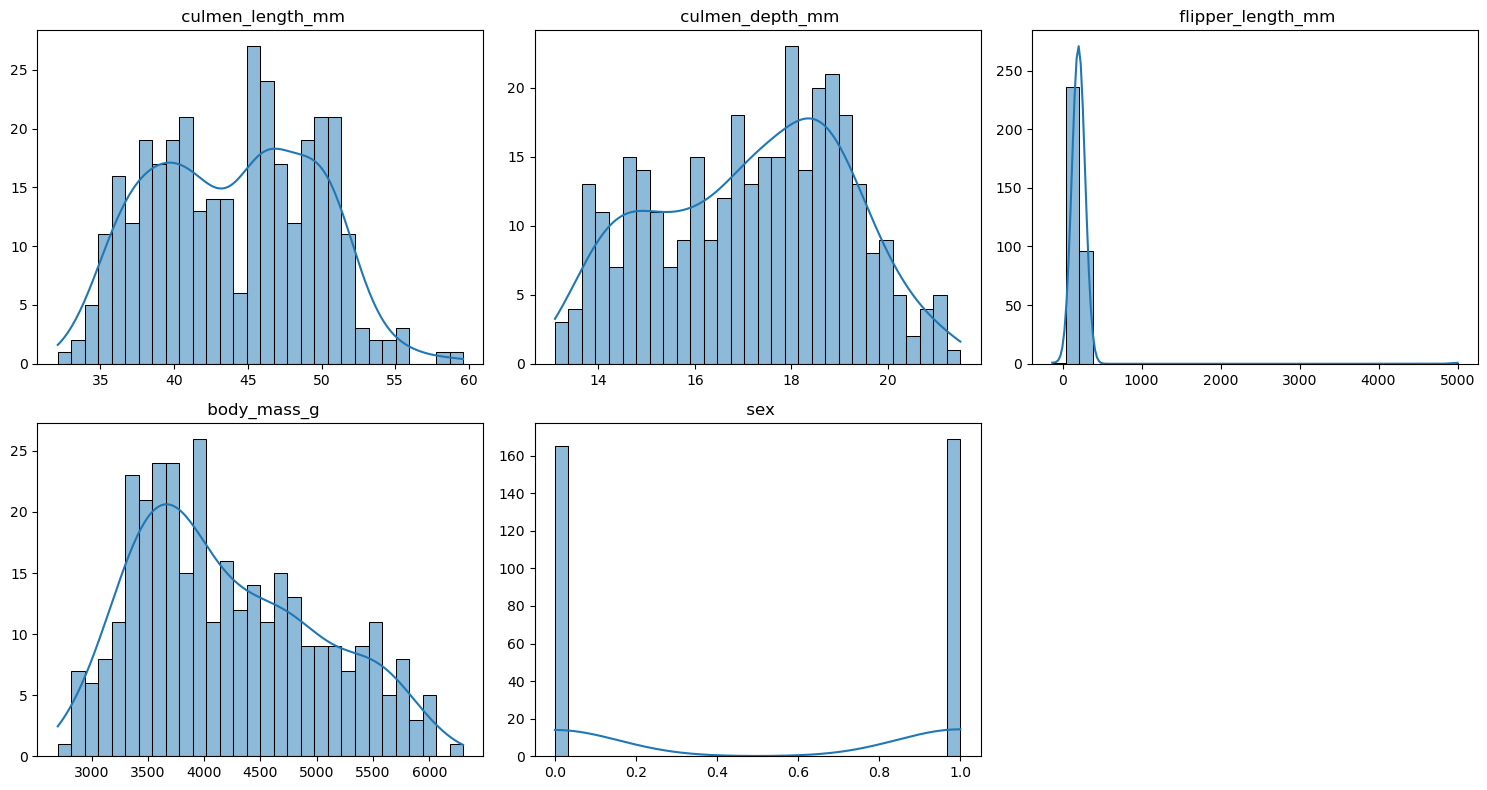

In [12]:
plot_all_histograms(df)

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
culmen_length_mm,334.0,43.986826,5.461540,32.1,39.5,44.45,48.575,59.6
culmen_depth_mm,334.0,17.173952,1.973277,13.1,15.6,17.30,18.700,21.5
flipper_length_mm,334.0,214.347305,263.648447,-132.0,190.0,197.00,213.000,5000.0
body_mass_g,334.0,4207.185629,804.009294,2700.0,3550.0,4050.00,4768.750,6300.0
sex,334.0,0.505988,0.500714,0.0,0.0,1.00,1.000,1.0


In [14]:
df['flipper_length_mm'] = df['flipper_length_mm'].replace(-132, 132)

In [15]:
q1=df['flipper_length_mm'].quantile(0.25)
q3=df['flipper_length_mm'].quantile(0.75)
IQR=q3-q1

UpperBound=q3+(1.5*IQR)
LowerBound=q1-(1.5*IQR)
df= df[(df['flipper_length_mm'] >= LowerBound) & (df['flipper_length_mm'] <= UpperBound)]

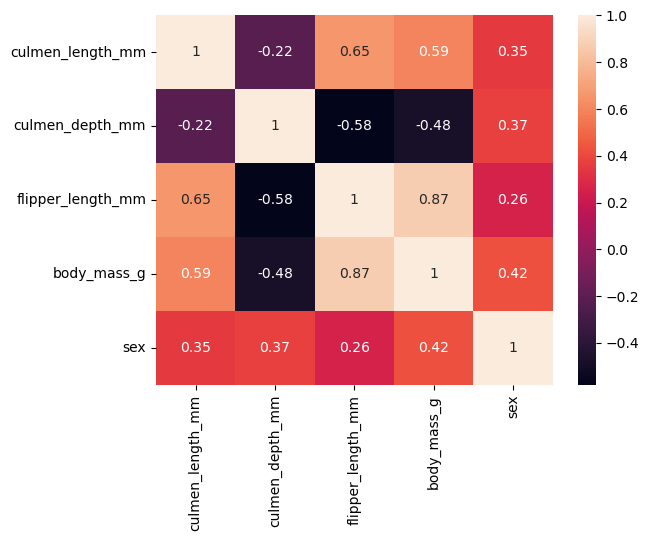

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [17]:
from sklearn.preprocessing import MinMaxScaler

In [18]:
scaler = MinMaxScaler()

In [19]:
df_scaled = scaler.fit_transform(df)

In [20]:
df = pd.DataFrame(df_scaled, columns=df.columns)

In [21]:
df.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,0.254545,0.666667,0.152542,0.291667,1.0
1,0.269091,0.511905,0.237288,0.305556,0.0
2,0.298182,0.583333,0.389831,0.152778,0.0
3,0.167273,0.738095,0.355932,0.208333,0.0
4,0.261818,0.892857,0.305085,0.263889,1.0


In [22]:
from sklearn.cluster import KMeans

In [23]:
wcss=[]
for k in range(1,16):
    model=KMeans(n_clusters=k,max_iter=300)
    model.fit(df)
    wcss.append(model.inertia_)


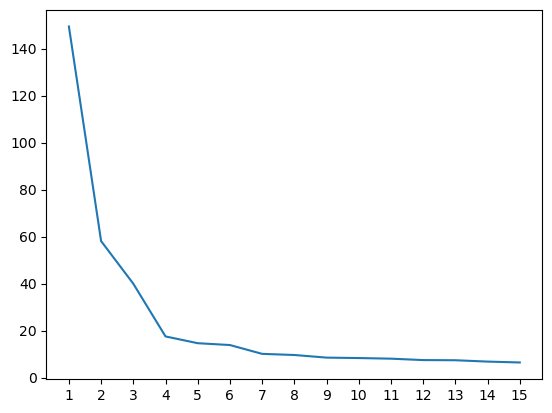

In [24]:
plt.plot(range(1,16),wcss)
plt.xticks(range(1,16))
plt.show()

In [25]:
model = KMeans(n_clusters=4)
model.fit(df)

KMeans(n_clusters=4)

In [26]:
labels =model.labels_

In [27]:
from sklearn.metrics import silhouette_score

In [28]:
silhouette_score(df,labels)

0.6152910198710603

In [29]:
df['clusters']=model.predict(df)

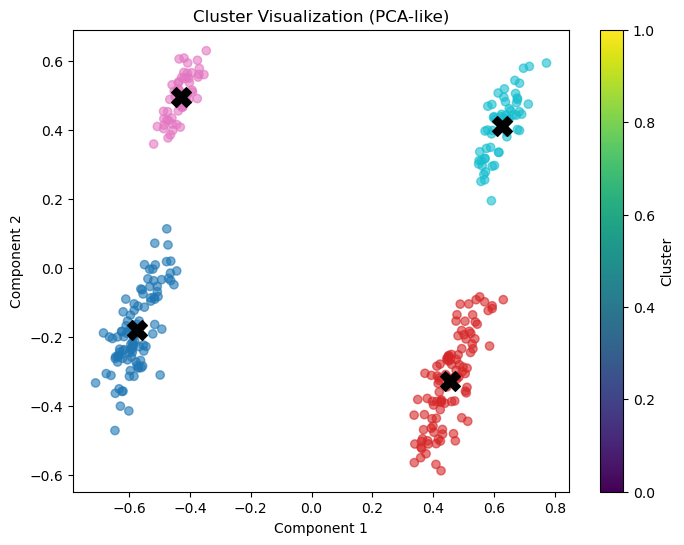

In [72]:
from sklearn.decomposition import PCA

X = df.drop("clusters", axis=1)

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(X)

centers = pca.transform(model.cluster_centers_)
plt.figure(figsize=(9,6))

plt.scatter(reduced_data[:,0],
            reduced_data[:,1],
            c=df["clusters"],
            cmap="tab10",
            s=60,
            alpha=0.6)

plt.scatter(centers[:,0],
            centers[:,1],
            s=250,
            c="red",
            edgecolor="black",
            label="Centroids")

plt.title("KMeans Clusters with Centroids (PCA)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.legend()
plt.tight_layout()
plt.show()
